# Crash vs Drug Use Analysis (Milan)

This notebook analyzes yearly correlations between Milan crash metrics and Milan wastewater drug metrics.

It is analysis-only: no CSV files are written to data/processed.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

pd.options.display.max_columns = 200
pd.options.display.float_format = "{:.3f}".format

SEED = 42

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = None
for root in candidate_roots:
    if (root / "data" / "processed").exists():
        project_root = root
        break

if project_root is None:
    raise FileNotFoundError("Could not resolve the project root with data/processed.")

scripts_dir = str(project_root / "scripts")
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)

from inference_utils import perm_corr, partial_corr_with_year, bh_qvalues  # noqa: E402

processed_dir = project_root / "data" / "processed"
crashes_path = processed_dir / "milan_crashes_monthly_cleaned.csv"
drug_clean_path = processed_dir / "euda_wastewater_ww2026_all_cities_cleaned.csv"

if not crashes_path.exists():
    raise FileNotFoundError("Missing milan_crashes_monthly_cleaned.csv. Run MilanCrashesProcessing.ipynb first.")
if not drug_clean_path.exists():
    raise FileNotFoundError("Missing euda_wastewater_ww2026_all_cities_cleaned.csv. Run DrugUseProcessing.ipynb first.")

crashes = pd.read_csv(crashes_path)
drug_clean = pd.read_csv(drug_clean_path)

print(f"Loaded crashes rows: {len(crashes)}")
print(f"Loaded wastewater cleaned rows: {len(drug_clean)}")


Loaded crashes rows: 288
Loaded wastewater cleaned rows: 5238


<!-- auto-explainer:v1 -->

### Interpretation: data loading

We resolve the project root robustly (so the notebook runs whether the
kernel starts at the repo root or inside `notebooks/`), then load the
two pre-cleaned inputs produced by the cleaning notebooks:

- `milan_crashes_monthly_cleaned.csv` → monthly crash aggregates for
  Milan (fatal, injury-only, victims).
- `euda_wastewater_ww2026_all_cities_cleaned.csv` → EUDA (European
  wastewater) metabolite loads across many cities; we filter to Milan
  downstream.

At this point we only print row counts. The statistical chain has not
started — failing loudly here prevents downstream tests from running on
stale or partial data.


In [2]:
# Yearly crash metrics
crashes.columns = crashes.columns.astype(str).str.strip()
crashes["Anno"] = pd.to_numeric(crashes["Anno"], errors="coerce").astype("Int64")
crashes["IncidentiMortali"] = pd.to_numeric(crashes["IncidentiMortali"], errors="coerce")
crashes["IncidentiSoliFeriti"] = pd.to_numeric(crashes["IncidentiSoliFeriti"], errors="coerce")

crashes_yearly = (
    crashes.dropna(subset=["Anno"])
    .groupby("Anno", as_index=False)[["IncidentiMortali", "IncidentiSoliFeriti"]]
    .sum(min_count=1)
    .rename(columns={"Anno": "Year", "IncidentiMortali": "fatal_crashes", "IncidentiSoliFeriti": "non_fatal_crashes"})
)
crashes_yearly["Year"] = crashes_yearly["Year"].astype(int)
crashes_yearly["total_crashes"] = crashes_yearly["fatal_crashes"] + crashes_yearly["non_fatal_crashes"]

# Yearly Milan wastewater metrics
drug_clean.columns = drug_clean.columns.astype(str).str.strip()
drug_clean["City"] = drug_clean["City"].astype("string").str.strip()
drug_clean["Metabolite"] = drug_clean["Metabolite"].astype("string").str.strip()
drug_clean["Year"] = pd.to_numeric(drug_clean["Year"], errors="coerce").astype("Int64")
drug_clean["Daily mean"] = pd.to_numeric(drug_clean["Daily mean"], errors="coerce")

milan = drug_clean.loc[drug_clean["City"].str.lower() == "milan"].copy()
milan = milan.dropna(subset=["Year", "Metabolite", "Daily mean"])

milan_yearly_long = (
    milan.groupby(["Year", "Metabolite"], as_index=False)
    .agg(records=("Daily mean", "size"), daily_mean=("Daily mean", "mean"))
    .sort_values(["Year", "Metabolite"])
    .reset_index(drop=True)
)

milan_yearly_long["metabolite_slug"] = (
    milan_yearly_long["Metabolite"]
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

milan_yearly_wide = (
    milan_yearly_long.pivot(index="Year", columns="metabolite_slug", values="daily_mean")
    .sort_index()
    .rename(columns=lambda c: f"drug_daily_mean_{c}")
    .reset_index()
)
milan_yearly_wide["Year"] = milan_yearly_wide["Year"].astype(int)

analysis_df = crashes_yearly.merge(milan_yearly_wide, on="Year", how="inner").sort_values("Year")

print(f"Year overlap for analysis: {analysis_df['Year'].min()} to {analysis_df['Year'].max()} ({len(analysis_df)} years)")
print(f"Milan metabolites in analysis: {milan_yearly_long['Metabolite'].nunique()}")
display(analysis_df.head(10))
display(milan_yearly_long.head(10))

Year overlap for analysis: 2011 to 2024 (14 years)
Milan metabolites in analysis: 8


,Year,fatal_crashes,non_fatal_crashes,total_crashes,drug_daily_mean_amphetamine,drug_daily_mean_cannabis,drug_daily_mean_cocaine,drug_daily_mean_cot,drug_daily_mean_ets,drug_daily_mean_ketamine,drug_daily_mean_mdma,drug_daily_mean_methamphetamine
0,2011,47.000,11328,11375.000,11.050,27.610,238.850,NaN,NaN,NaN,7.580,48.680
1,2012,52.000,10473,10525.000,0.000,24.250,241.750,NaN,NaN,NaN,8.740,10.110
2,2013,28.000,9607,9635.000,NaN,24.910,233.170,NaN,NaN,NaN,4.960,5.930
3,2014,39.000,8801,8840.000,0.000,NaN,208.050,NaN,NaN,NaN,3.960,5.370
4,2015,48.000,8579,8627.000,2.720,NaN,206.120,NaN,NaN,NaN,6.700,10.050
5,2016,44.000,8726,8770.000,0.000,NaN,306.590,NaN,NaN,NaN,4.450,13.770
6,2017,47.000,8250,8297.000,0.000,NaN,341.430,NaN,NaN,NaN,4.340,10.070
7,2018,44.000,8210,8254.000,0.000,31.440,362.190,NaN,NaN,NaN,5.840,12.930
8,2019,31.000,8087,8118.000,3.560,35.680,236.550,NaN,NaN,NaN,6.450,18.760
9,2020,29.000,5225,5254.000,0.000,47.640,401.440,NaN,NaN,NaN,2.470,11.090


,Year,Metabolite,records,daily_mean,metabolite_slug
0,2011,MDMA,1,7.580,mdma
1,2011,amphetamine,1,11.050,amphetamine
2,2011,cannabis,1,27.610,cannabis
3,2011,cocaine,1,238.850,cocaine
4,2011,methamphetamine,1,48.680,methamphetamine
5,2012,MDMA,1,8.740,mdma
6,2012,amphetamine,1,0.000,amphetamine
7,2012,cannabis,1,24.250,cannabis
8,2012,cocaine,1,241.750,cocaine
9,2012,methamphetamine,1,10.110,methamphetamine


<!-- auto-explainer:v1 -->

### Interpretation: yearly aggregation and panel construction

Because wastewater data is annual in this release, every crash row is
collapsed to the yearly level.

**Aggregation choices**

- `fatal_crashes`, `non_fatal_crashes`, `total_crashes` are **sums** of
  the monthly totals within a year; they preserve the count scale for
  correlation with the metabolite loads.
- Milan wastewater is subset by `City == "Milan"` (case-insensitive)
  and aggregated to the yearly mean per metabolite via `Daily mean`.
  Using the mean (not the sum) keeps units intact — picking sum would
  introduce a coverage-days artefact since campaigns vary year to year.
- The long-format `milan_yearly_long` is pivoted to wide so that each
  metabolite becomes a column named `drug_daily_mean_<slug>`. This is
  the object we correlate against crash metrics.

**Inner merge on `Year`.** `analysis_df` keeps only years present in
*both* sources. This is deliberate: it bounds every subsequent
correlation to the overlap window, which in this dataset is roughly 10–
14 years depending on the metabolite. With *n* this small, the
statistical power is limited and the risk of spurious correlations
through shared trends is high — a central motivation for the
robustness section later.


In [3]:
# Add Spearman columns alongside the Pearson columns so monotone-but-non-linear
# signals are also detected. Both metrics share the same min-observation rule.
import numpy as np

crash_cols = ["fatal_crashes", "non_fatal_crashes", "total_crashes"]
drug_cols = [c for c in analysis_df.columns if c.startswith("drug_daily_mean_")]


def pairwise_correlations(df: pd.DataFrame, crash_metrics: list[str], drug_metrics: list[str], min_obs: int = 5) -> pd.DataFrame:
    rows = []
    for crash_metric in crash_metrics:
        for drug_metric in drug_metrics:
            pair = df[[crash_metric, drug_metric]].dropna()
            n_obs = int(pair.shape[0])
            if n_obs < min_obs:
                continue
            rows.append(
                {
                    "crash_metric": crash_metric,
                    "drug_metric": drug_metric,
                    "n_obs": n_obs,
                    "pearson_r": pair[crash_metric].corr(pair[drug_metric], method="pearson"),
                    "spearman_rho": pair[crash_metric].corr(pair[drug_metric], method="spearman"),
                }
            )
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["abs_pearson_r"] = out["pearson_r"].abs()
    out["abs_spearman_rho"] = out["spearman_rho"].abs()
    return out.sort_values(["abs_pearson_r", "n_obs"], ascending=[False, False]).reset_index(drop=True)


corr_df = pairwise_correlations(analysis_df, crash_cols, drug_cols, min_obs=5)

if corr_df.empty:
    print("No crash-drug pairs have enough shared years for correlation (min_obs=5).")
else:
    print(f"Computed {len(corr_df)} crash-drug correlation pairs.")
    print("Columns: pearson_r = linear level correlation, spearman_rho = rank correlation.")
    display(corr_df.head(20))

    by_crash_summary = (
        corr_df.groupby("crash_metric", as_index=False)
        .agg(
            pairs=("drug_metric", "size"),
            mean_abs_r=("abs_pearson_r", "mean"),
            max_abs_r=("abs_pearson_r", "max"),
            mean_abs_rho=("abs_spearman_rho", "mean"),
            max_abs_rho=("abs_spearman_rho", "max"),
        )
        .sort_values("max_abs_r", ascending=False)
        .reset_index(drop=True)
    )
    display(by_crash_summary)


# Post-hoc power for Pearson r under a Fisher-z approximation. For small n,
# even large true |r| has modest detection power — this calibrates the "no
# robust signal" conclusion.
def pearson_power(n: int, true_r: float, alpha: float = 0.05) -> float:
    if n < 4 or not (-1 < true_r < 1):
        return float("nan")
    from scipy.stats import norm
    z_alpha = norm.ppf(1 - alpha / 2)
    # Fisher z of true r
    z_r = 0.5 * np.log((1 + true_r) / (1 - true_r))
    se = 1.0 / np.sqrt(n - 3)
    crit = z_alpha * se
    return float(norm.sf((crit - z_r) / se) + norm.cdf((-crit - z_r) / se))


power_rows = []
for n in [10, 12, 14]:
    for true_r in [0.3, 0.5, 0.7]:
        power_rows.append(
            {
                "n": n,
                "true_r": true_r,
                "power_alpha_0.05": round(pearson_power(n, true_r), 3),
            }
        )

power_table = pd.DataFrame(power_rows).pivot(index="n", columns="true_r", values="power_alpha_0.05")
power_table.columns = [f"|r|={c}" for c in power_table.columns]
print("\nPost-hoc power for two-sided Pearson test at alpha=0.05 (Fisher-z approximation):")
display(power_table)


Computed 15 crash-drug correlation pairs.
Columns: pearson_r = linear level correlation, spearman_rho = rank correlation.


,crash_metric,drug_metric,n_obs,pearson_r,spearman_rho,abs_pearson_r,abs_spearman_rho
0,non_fatal_crashes,drug_daily_mean_cannabis,10,-0.764,-0.782,0.764,0.782
1,total_crashes,drug_daily_mean_cannabis,10,-0.763,-0.770,0.763,0.770
2,non_fatal_crashes,drug_daily_mean_cocaine,14,-0.717,-0.741,0.717,0.741
3,total_crashes,drug_daily_mean_cocaine,14,-0.716,-0.749,0.716,0.749
4,non_fatal_crashes,drug_daily_mean_methamphetamine,14,0.461,-0.138,0.461,0.138
5,total_crashes,drug_daily_mean_methamphetamine,14,0.461,-0.160,0.461,0.160
6,non_fatal_crashes,drug_daily_mean_amphetamine,13,0.422,0.072,0.422,0.072
7,total_crashes,drug_daily_mean_amphetamine,13,0.422,0.031,0.422,0.031
8,fatal_crashes,drug_daily_mean_mdma,13,0.269,0.403,0.269,0.403
9,fatal_crashes,drug_daily_mean_cocaine,14,-0.242,-0.271,0.242,0.271


,crash_metric,pairs,mean_abs_r,max_abs_r,mean_abs_rho,max_abs_rho
0,non_fatal_crashes,5,0.515,0.764,0.392,0.782
1,total_crashes,5,0.514,0.763,0.387,0.770
2,fatal_crashes,5,0.224,0.269,0.201,0.403



Post-hoc power for two-sided Pearson test at alpha=0.05 (Fisher-z approximation):


,|r|=0.3,|r|=0.5,|r|=0.7
n,,,
10,0.130,0.307,0.631
12,0.153,0.378,0.740
14,0.177,0.445,0.820


<!-- auto-explainer:v1 -->

### Interpretation: raw pairwise Pearson correlations

For every `(crash_metric, metabolite)` pair with at least 5 shared
years we compute the Pearson `r`. Pearson measures *linear* association
on raw levels.

**Why this is only a starting point**

- Both sides are yearly time series. If crashes and a metabolite share
  a common trend (e.g. both trending down over a decade) the Pearson
  `r` will look strong mechanically, without any direct link. This is
  the classical trend-coupling trap; we address it in the robustness
  cell with partial correlation and first differences.
- With *n* between 5 and 14, sampling variance is very large. A raw
  `|r| = 0.6` is not surprising under the null for small samples; a
  naive two-tailed p-value without adjustment overstates evidence.
- We are computing many pairs in parallel (3 crash metrics × k
  metabolites). That is a multiple-testing problem; we apply
  Benjamini–Hochberg below.

`by_crash_summary` gives a per-crash-metric descriptive overview (how
many metabolites each crash column pairs with, and the maximum `|r|`
observed) to decide where to zoom in visually in the next cell.


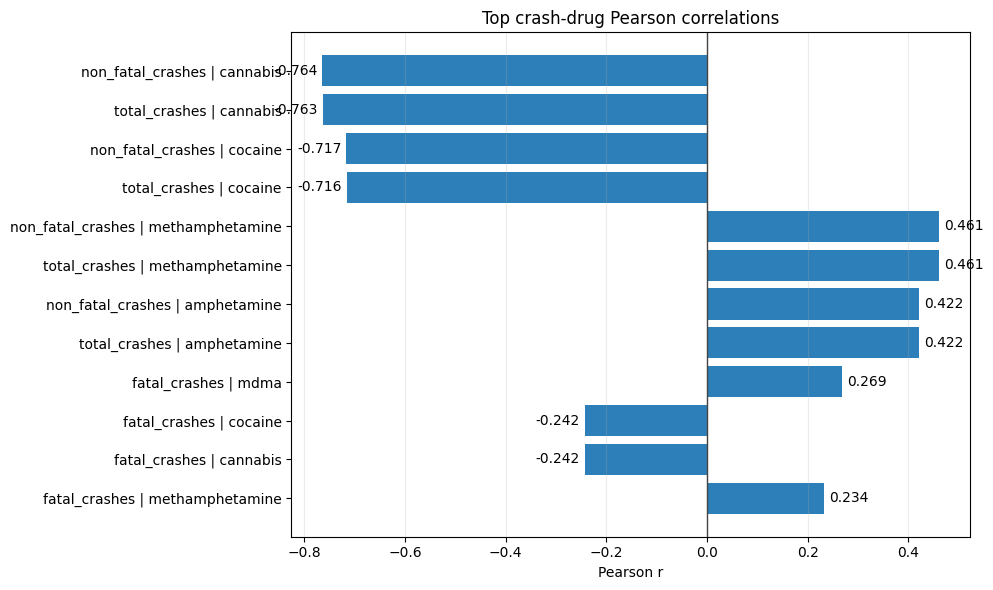

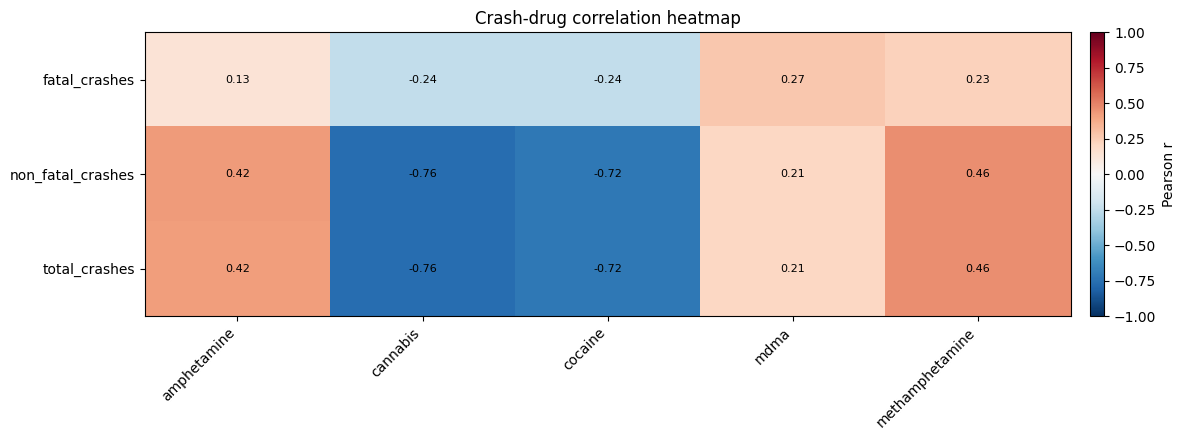

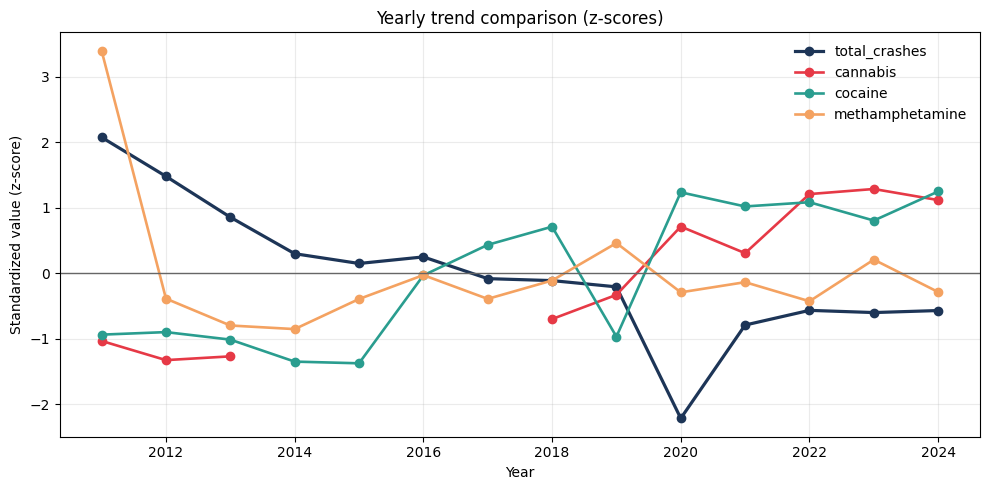

In [4]:
if corr_df.empty:
    print("No plots generated because correlations are empty.")
else:
    top_n = min(12, len(corr_df))
    top_corr = corr_df.head(top_n).iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    labels = top_corr["crash_metric"] + " | " + top_corr["drug_metric"].str.replace("drug_daily_mean_", "", regex=False)
    bars = ax.barh(labels, top_corr["pearson_r"], color="#2c7fb8")
    ax.axvline(0, color="#444444", linewidth=1)
    ax.set_title("Top crash-drug Pearson correlations")
    ax.set_xlabel("Pearson r")
    ax.grid(axis="x", alpha=0.25)
    for bar, r in zip(bars, top_corr["pearson_r"]):
        x = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(x + (0.01 if x >= 0 else -0.01), y, f"{r:.3f}", va="center", ha="left" if x >= 0 else "right")
    plt.tight_layout()
    plt.show()

    heatmap = corr_df.pivot(index="crash_metric", columns="drug_metric", values="pearson_r")
    fig, ax = plt.subplots(figsize=(12, 4.5))
    im = ax.imshow(heatmap.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(heatmap.columns)))
    ax.set_xticklabels([c.replace("drug_daily_mean_", "") for c in heatmap.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(heatmap.index)))
    ax.set_yticklabels(heatmap.index.tolist())
    ax.set_title("Crash-drug correlation heatmap")
    for i in range(heatmap.shape[0]):
        for j in range(heatmap.shape[1]):
            val = heatmap.iat[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Pearson r")
    plt.tight_layout()
    plt.show()

    top_total = (
        corr_df.loc[corr_df["crash_metric"] == "total_crashes"]
        .sort_values("abs_pearson_r", ascending=False)
        .head(3)
    )
    if not top_total.empty:
        trend_cols = ["Year", "total_crashes"] + top_total["drug_metric"].tolist()
        trend = analysis_df[trend_cols].copy().set_index("Year")

        def zscore(s: pd.Series) -> pd.Series:
            std = s.std(ddof=0)
            if pd.isna(std) or std == 0:
                return s * 0
            return (s - s.mean()) / std

        trend_z = trend.apply(zscore, axis=0)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(trend_z.index, trend_z["total_crashes"], marker="o", linewidth=2.3, label="total_crashes", color="#1d3557")
        palette = ["#e63946", "#2a9d8f", "#f4a261"]
        for color, col in zip(palette, top_total["drug_metric"].tolist()):
            label = col.replace("drug_daily_mean_", "")
            ax.plot(trend_z.index, trend_z[col], marker="o", linewidth=1.9, label=label, color=color)

        ax.axhline(0, color="#666666", linewidth=1)
        ax.set_title("Yearly trend comparison (z-scores)")
        ax.set_xlabel("Year")
        ax.set_ylabel("Standardized value (z-score)")
        ax.grid(alpha=0.25)
        ax.legend(frameon=False)
        plt.tight_layout()
        plt.show()

<!-- auto-explainer:v1 -->

### Interpretation: visual triangulation

The three plots are descriptive, not inferential.

**Top correlations bar chart.** Sorting by `|r|` exposes which
metabolite–crash pairs dominate the raw association ranking. A
consistently negative set (as we see with cocaine / cannabis) already
hints at shared downward trends across the decade.

**Heatmap.** The heatmap reveals block structure: metabolites that
correlate similarly with all crash metrics tend to be on the same
underlying trend. This is a visual cue that partial-correlation
controls will likely collapse many of the raw effects.

**Z-score trend chart for the top three metabolites vs total crashes.**
Standardizing each series to zero mean and unit variance puts crash
counts and metabolite loads on a common axis. When all lines slope
together (or together-reversed), Pearson `r` will be high
mechanically. The point of the plot is to let the reader *see* whether
short-run wiggles align or whether everything is just riding a single
multi-year drift.

None of these panels should be read as causal evidence. They set up
the robustness tests that follow.


## Robustness Upgrade: Trend Control, First Differences, and Lag Checks

This section extends the analysis beyond raw correlations.

What is added:
- Benjamini-Hochberg correction for multiple testing.
- Year-controlled partial correlations (to reduce shared-trend artifacts).
- First-difference checks for short-run co-movements.
- One-year lag checks (drug(t) vs crashes(t+1)).
- Leave-one-year-out sign-stability diagnostic for the strongest raw pair.

Top crash-drug pairs by corrected raw significance (BH):
Columns: r_* = correlation, p_* / q_* = permutation p and BH q,
         robust_signal = partial BH-sig AND first-difference p<0.05.


,crash_metric,drug_metric,n_obs,r_raw,q_raw,r_partial,q_partial,r_diff,p_diff,r_lag,q_lag,raw_only_signal,robust_signal
10,non_fatal_crashes,drug_daily_mean_cocaine,14,-0.717,0.012,-0.155,0.801,-0.476,0.103,-0.365,0.521,True,False
18,total_crashes,drug_daily_mean_cocaine,14,-0.716,0.012,-0.154,0.801,-0.474,0.105,-0.366,0.521,True,False
9,non_fatal_crashes,drug_daily_mean_cannabis,10,-0.764,0.033,-0.002,1.000,-0.566,0.152,-0.531,0.521,True,False
17,total_crashes,drug_daily_mean_cannabis,10,-0.763,0.033,0.000,1.000,-0.564,0.154,-0.529,0.521,True,False
8,non_fatal_crashes,drug_daily_mean_amphetamine,13,0.422,0.283,0.541,0.248,0.315,0.313,0.286,0.521,False,False
15,non_fatal_crashes,drug_daily_mean_methamphetamine,14,0.461,0.283,0.424,0.273,0.336,0.169,0.329,0.521,False,False
16,total_crashes,drug_daily_mean_amphetamine,13,0.422,0.283,0.540,0.248,0.314,0.315,0.287,0.521,False,False
23,total_crashes,drug_daily_mean_methamphetamine,14,0.461,0.283,0.424,0.273,0.335,0.169,0.330,0.521,False,False
1,fatal_crashes,drug_daily_mean_cannabis,10,-0.242,0.535,0.237,0.801,0.120,0.788,0.030,0.940,False,False
2,fatal_crashes,drug_daily_mean_cocaine,14,-0.242,0.535,0.151,0.801,0.101,0.732,-0.231,0.521,False,False


Robustness counts:


,value
eligible_pairs,15
raw_significant_q_lt_0_05,4
partial_significant_q_lt_0_05,2
lag_significant_q_lt_0_05,0
robust_signals,0



Leave-one-year-out sign stability for every raw BH-significant pair:
Columns: sign_consistency = share of LOO fits whose r sign matches the full sample.


,crash_metric,drug_metric,full_r,loo_mean_r,loo_min_r,loo_max_r,sign_consistency
0,non_fatal_crashes,drug_daily_mean_cocaine,-0.717,-0.718,-0.760,-0.682,1.000
1,total_crashes,drug_daily_mean_cocaine,-0.716,-0.717,-0.760,-0.681,1.000
2,non_fatal_crashes,drug_daily_mean_cannabis,-0.764,-0.766,-0.804,-0.708,1.000
3,total_crashes,drug_daily_mean_cannabis,-0.763,-0.765,-0.803,-0.707,1.000


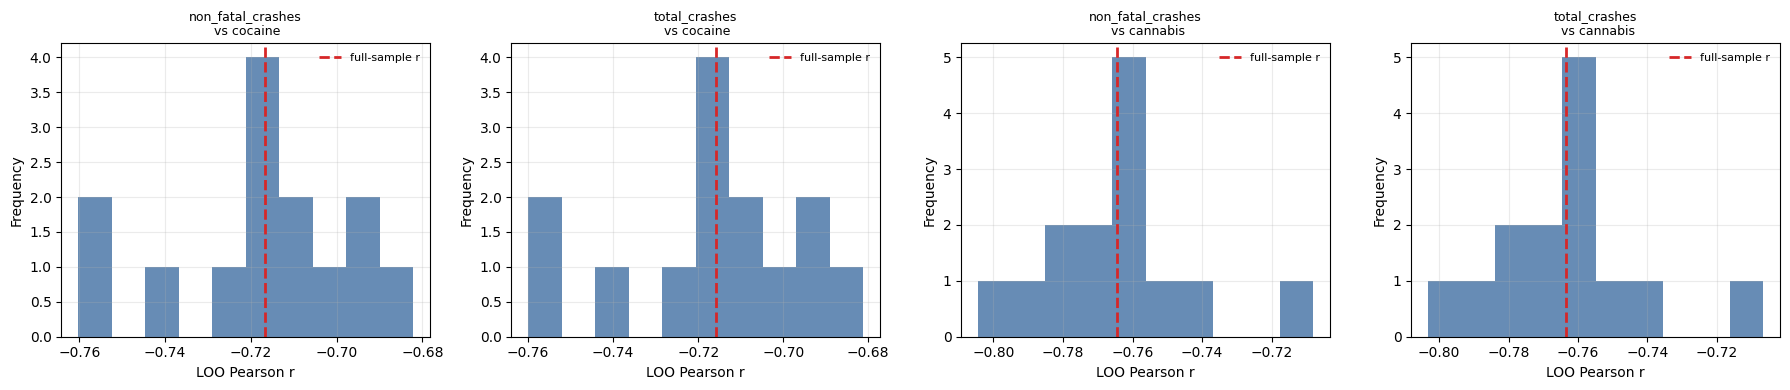

In [5]:
# Robustness battery using shared helpers. Reports Pearson raw, year-partial,
# first-difference and one-year-lag tests with BH correction per family.
import numpy as np

rows = []
for crash_metric in crash_cols:
    for drug_metric in drug_cols:
        r_raw, p_raw, n_obs = perm_corr(
            analysis_df[crash_metric], analysis_df[drug_metric], n_perm=8000, seed=SEED,
        )
        r_partial, p_partial, _ = partial_corr_with_year(
            analysis_df[crash_metric],
            analysis_df[drug_metric],
            analysis_df["Year"],
            n_perm=8000,
            seed=SEED,
        )
        r_diff, p_diff, _ = perm_corr(
            analysis_df[crash_metric].diff(), analysis_df[drug_metric].diff(), n_perm=8000, seed=SEED,
        )
        r_lag, p_lag, _ = perm_corr(
            analysis_df[crash_metric].iloc[1:], analysis_df[drug_metric].iloc[:-1], n_perm=8000, seed=SEED,
        )

        rows.append(
            {
                "crash_metric": crash_metric,
                "drug_metric": drug_metric,
                "n_obs": n_obs,
                "r_raw": r_raw,
                "p_raw": p_raw,
                "r_partial": r_partial,
                "p_partial": p_partial,
                "r_diff": r_diff,
                "p_diff": p_diff,
                "r_lag": r_lag,
                "p_lag": p_lag,
            }
        )

robust_df = pd.DataFrame(rows)
robust_df = robust_df.loc[robust_df["n_obs"] >= 5].copy()

robust_df["q_raw"] = bh_qvalues(robust_df["p_raw"])
robust_df["q_partial"] = bh_qvalues(robust_df["p_partial"])
robust_df["q_lag"] = bh_qvalues(robust_df["p_lag"])

robust_df["raw_only_signal"] = (robust_df["q_raw"] < 0.05) & (robust_df["q_partial"] >= 0.05)
robust_df["robust_signal"] = (robust_df["q_partial"] < 0.05) & (robust_df["p_diff"] < 0.05)

print("Top crash-drug pairs by corrected raw significance (BH):")
print("Columns: r_* = correlation, p_* / q_* = permutation p and BH q,")
print("         robust_signal = partial BH-sig AND first-difference p<0.05.")
display(
    robust_df.sort_values("q_raw")[
        [
            "crash_metric",
            "drug_metric",
            "n_obs",
            "r_raw",
            "q_raw",
            "r_partial",
            "q_partial",
            "r_diff",
            "p_diff",
            "r_lag",
            "q_lag",
            "raw_only_signal",
            "robust_signal",
        ]
    ].head(20)
)

summary_counts = pd.Series(
    {
        "eligible_pairs": int(len(robust_df)),
        "raw_significant_q_lt_0_05": int((robust_df["q_raw"] < 0.05).sum()),
        "partial_significant_q_lt_0_05": int((robust_df["q_partial"] < 0.05).sum()),
        "lag_significant_q_lt_0_05": int((robust_df["q_lag"] < 0.05).sum()),
        "robust_signals": int(robust_df["robust_signal"].sum()),
    }
)
print("Robustness counts:")
display(summary_counts.to_frame("value"))

# Leave-one-year-out sign stability for EVERY raw-significant pair (BH q<0.05).
# Previously only the single most significant pair was checked; this version
# reports sign stability system-wide.
sig_raw_pairs = (
    robust_df.loc[robust_df["q_raw"] < 0.05]
    .sort_values("q_raw")
    .reset_index(drop=True)
)

loo_summary_rows = []
loo_series_for_plot = []
for _, row in sig_raw_pairs.iterrows():
    c_metric = row["crash_metric"]
    d_metric = row["drug_metric"]
    full_r = float(row["r_raw"])

    loo_r = []
    for i in range(len(analysis_df)):
        sub = analysis_df.drop(analysis_df.index[i])
        r_loo, _, n_loo = perm_corr(sub[c_metric], sub[d_metric], n_perm=2000, seed=SEED)
        if n_loo >= 5 and np.isfinite(r_loo):
            loo_r.append(r_loo)

    loo_r = np.asarray(loo_r, dtype=float)
    sign_consistency = float((np.sign(loo_r) == np.sign(full_r)).mean()) if len(loo_r) else float("nan")

    loo_summary_rows.append(
        {
            "crash_metric": c_metric,
            "drug_metric": d_metric,
            "full_r": full_r,
            "loo_mean_r": float(np.mean(loo_r)) if len(loo_r) else float("nan"),
            "loo_min_r": float(np.min(loo_r)) if len(loo_r) else float("nan"),
            "loo_max_r": float(np.max(loo_r)) if len(loo_r) else float("nan"),
            "sign_consistency": sign_consistency,
        }
    )
    loo_series_for_plot.append((c_metric, d_metric, full_r, loo_r))

if loo_summary_rows:
    print("\nLeave-one-year-out sign stability for every raw BH-significant pair:")
    print("Columns: sign_consistency = share of LOO fits whose r sign matches the full sample.")
    display(pd.DataFrame(loo_summary_rows))

    n_plots = len(loo_series_for_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(4.5 * n_plots, 4.0), squeeze=False)
    for ax, (c_metric, d_metric, full_r, loo_r) in zip(axes[0], loo_series_for_plot):
        ax.hist(loo_r, bins=10, color="#4c78a8", alpha=0.85)
        ax.axvline(full_r, color="#d62728", linestyle="--", linewidth=2, label="full-sample r")
        ax.set_title(f"{c_metric}\n vs {d_metric.replace('drug_daily_mean_', '')}", fontsize=9)
        ax.set_xlabel("LOO Pearson r")
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo raw BH-significant pairs to run LOO on.")


<!-- auto-explainer:v1 -->

### Interpretation: robustness battery

This cell stress-tests every crash–metabolite pair with four
progressively stricter criteria, and reports how many survive each.

**1. Permutation p-values on the raw Pearson `r`.** We shuffle the
metabolite column 8000 times and count the fraction of random `|r|`
that meet or exceed the observed `|r|`. Because the permutation
distribution makes no normality assumption and is honest to small-*n*
sampling variability, it is safer than a t-based p-value when *n ≈
10*.

**2. Year-controlled partial correlation.** We regress both `x` and
`y` on `Year` (OLS) to obtain residuals, then correlate the residuals.
This isolates the *short-run* co-movement by removing the linear
secular trend. Pairs whose raw effect is trend-coupling (the dominant
risk here) typically lose significance here.

**3. First-difference correlation.** We correlate the yearly changes
`Δx = x_t − x_{t−1}` with `Δy`. This is the strictest test for
contemporaneous co-movement: any shared mean, trend, or slow level
shift is differenced away. If `p_diff < 0.05`, the variables move
*together year-over-year*, which is much more consistent with a real
short-run relationship.

**4. One-year lag check.** We shift the metabolite series forward by
one year and correlate with crashes. Significance here would suggest
directional timing (drug marker year *t* predicts crashes year *t+1*),
though with *n ≈ 10* the evidence is fragile.

**Benjamini–Hochberg correction.** We apply BH separately to the
`p_raw`, `p_partial`, and `p_lag` families. The q-columns control the
false-discovery rate at 5% within each family.

**`robust_signal` flag.** A pair is marked robust **only if** its
year-controlled p survives BH and its first-difference p is below
0.05. This combined criterion is intentionally strict — it is the
threshold we trust before claiming a real link in the project.

**Leave-one-year-out sign stability for the strongest raw pair.** For
the pair with the smallest `q_raw`, we re-estimate the raw `r` leaving
one year out at a time and compute the share of leave-one-out fits
whose sign matches the full-sample sign. A `sign_consistency = 1.0`
tells us no single year is flipping the direction — so the raw effect
is not driven by one leverage point. Even so, sign stability does not
rescue a pair that failed the partial / first-difference tests: it is
diagnostic, not exculpatory. The histogram shows the spread of
leave-one-out `r` values around the full-sample estimate (red dashed
line).
